In [24]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

SEED = 42
np.random.seed(SEED)

# Algoritmo de *importance sampling*
- Utilizando las mismas distribuciones propuestas $q(x)$ (uniforme y gaussiana) y la función $f(x)$ de los ejercicios sobre *rejection sampling*.

In [ ]:
proposal_low = -5.0
proposal_high = 5.0
proposal_loc = 1.5
proposal_scale = np.sqrt(5.0)

def f(x):
    return (1 + np.exp(-x))**(-1)

def proposal_pdf1(x, low=proposal_low, high=proposal_high):
    return stats.uniform.pdf(x, loc=low, scale=(high - low))

def proposal_sampler1(size, low=proposal_low, high=proposal_high):
    return stats.uniform.rvs(loc=low, scale=(high - low), size=size)

def proposal_pdf2(x, loc=proposal_loc, scale=proposal_scale):
    return stats.norm.pdf(x, loc=loc, scale=scale)

def proposal_sampler2(size, loc=proposal_loc, scale=proposal_scale):
    return stats.norm.rvs(loc=loc, scale=scale, size=size)

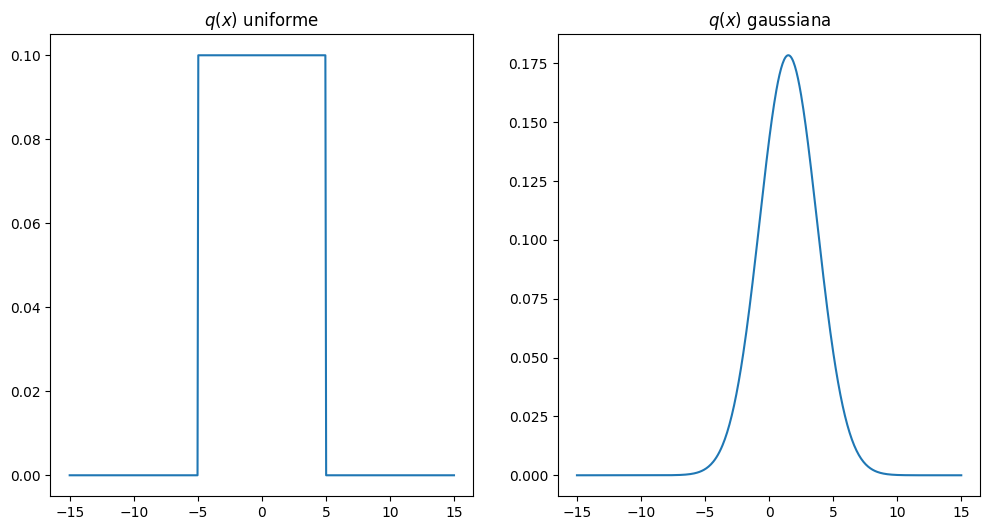

In [ ]:
# Visualizar las distribuciones propuestas
x = np.linspace(-15, 15, 500)
q_uniform_probs = proposal_pdf1(x)
q_gaussian_probs = proposal_pdf2(x)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(x, q_uniform_probs)
axs[0].set_title(r"$q(x)$ uniforme")
axs[1].plot(x, q_gaussian_probs)
axs[1].set_title(r"$q(x)$ gaussiana")
plt.show()

1. Elegir una distribución $p(x)$ para estimar $\mathbb{E}_{x \sim p}[f(x)]$ con $f(x) = \frac{1}{(1 + e^{-x})} = (1 + e^{-x})^{-1}$.

In [27]:
def f(x):
    return (1 + np.exp(-x))**(-1)

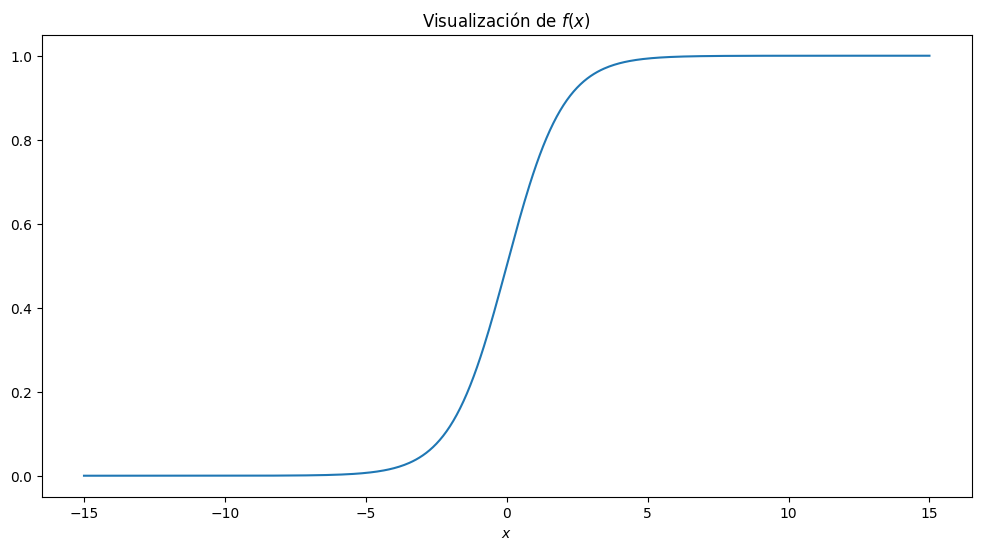

In [28]:
# Visualizar f(x)
plt.figure(figsize=(12, 6))
plt.plot(x, f(x))
plt.xlabel(r"$x$")
plt.title(r"Visualización de $f(x)$")
plt.show()

In [ ]:
def basic_importance_sampling(f, p_pdf, q_pdf, q_sampling, num_samples):
    samples = q_sampling(num_samples)
    p_xi = p_pdf(samples)
    q_xi = q_pdf(samples)
    weights = p_xi / q_xi
    f_values = f(samples)
    estimated_expectation = np.mean(f_values * weights)
    return estimated_expectation, samples, weights